In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

project_path = '/content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1'
os.chdir(project_path)

print("Current Directory:", os.getcwd())

Current Directory: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1


In [3]:
!ls -la experiments/exp4b_order_input_position/exp4b_order_input_pos_ph1.sh

-rw------- 1 root root 10952 Apr  5 15:18 experiments/exp4b_order_input_position/exp4b_order_input_pos_ph1.sh


In [4]:
import os

# Set your Informer data directory
informer_path = f'{project_path}/Informer2020-original'
data_dir = f'{informer_path}/data/ETT'
os.makedirs(data_dir, exist_ok=True)

# File path
data_file = f'{data_dir}/ETTh1.csv'

# Download ETTh1 dataset
if not os.path.exists(data_file):
    print("Downloading ETTh1.csv...")
    os.system(
        f'wget -q "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv" '
        f'-O "{data_file}"'
    )

# Verify
if os.path.exists(data_file):
    print(f"✅ Download successful: {data_file}")
else:
    print("❌ Download failed.")

✅ Download successful: /content/drive/MyDrive/Dist-Abl-PRL-All-Exs-ETTH1/Informer2020-original/data/ETT/ETTh1.csv


In [5]:
# Fix np.Inf -> np.inf in tools.py (removed in NumPy 2.0)
tools_path = f'{project_path}/Informer2020-original/utils/tools.py'

with open(tools_path, 'r') as f:
    content = f.read()

content_fixed = content.replace('np.Inf', 'np.inf')

with open(tools_path, 'w') as f:
    f.write(content_fixed)

print("✅ Fixed np.Inf -> np.inf in utils/tools.py")

✅ Fixed np.Inf -> np.inf in utils/tools.py


In [6]:
!bash experiments/exp4b_order_input_position/exp4b_order_input_pos_ph1.sh

Experiment 4b — Phase 1: Ordering on Positional Space
What is being tested:
  Embedding : value + temporal + ordering_operator(Legendre)
  Formula   : X'_i = X_i + T_i + O_i(P)
  O_i(P)    : (1/N-1) * sum_{j!=i} (P_i - P_j)
  Space     : Positional (Legendre), NOT semantic/value

Appendix experiment — mentor: 'I see no reason to do it'
Expected: MSE ~= exp3-LabelOnly (positional mean ~= 0)

Fixed config  : scaling=True (hardcoded in embed.py)
Seed          : 2021 (Phase 1 single seed)
Pred lengths  : 96, 192 (Phase 1 short + mid horizon)
Total runs    : 2
Start: Sun Apr  5 03:21:48 PM UTC 2026

Copying experiment files...
Files copied successfully.

------------------------------------------------------------
RUN 1/2: exp4b_ph1_ETTh1_order_pos_pred96_seed2021
pred_len=96 | seed=2021 | config=order_positional
Start: Sun Apr  5 03:21:52 PM UTC 2026
Args in experiment:
Namespace(model='informer', data='ETTh1', root_path='./data/ETT/', data_path='ETTh1.csv', features='M', target='OT', freq

## What I observe:

### Results:

- pred=96: MSE = 0.8118
- pred=192: MSE = 0.7896

This is the third decision case from the guide — unexpected. exp4b is NOT behaving like exp3 at all.

### Comparing against the full table:

- pred=96: beats Exp4-Ordering (0.8220), beats Exp2-LOD (0.8242), beats Exp1-Pre (0.8683) — best seen at 96  
- pred=192: 0.7896 is the best seen at 192 across every experiment — beats Exp3b (0.8888), beats Exp1-Pre (0.8463), beats everything  

This directly contradicts the mentor's intuition. The algebraic argument that O_i(P) ≈ P_i when mean(P) ≈ 0 would predict MSE ~1.099 at pred=96. Instead we got 0.8118. Mean-centering the Legendre vectors is doing something real and meaningful.

Also note: both pred_lens improving together — this is a stable pattern, not a mixed result.

## What to do next:

This is no longer just an appendix experiment. The result is strong enough that Phase 2 is mandatory. Proceed with:

- Seeds: 2021, 2022, 2023  
- pred_lens: 48, 96, 192, 336  
- 12 runs total  

Before I write the Phase 2 script — do you want to flag this to your mentor first given it overturns his expectation? And confirm the folder name is exactly exp4b_order_input_position.

In [7]:
!bash experiments/exp4b_order_input_position/exp4b_order_input_pos_ph2.sh

Experiment 4b — Phase 2: Ordering on Positional Space
What is being tested:
  Embedding : value + temporal + ordering_operator(Legendre)
  Formula   : X'_i = X_i + T_i + O_i(P)
  O_i(P)    : (1/N-1) * sum_{j!=i} (P_i - P_j)
  Space     : Positional (Legendre), NOT semantic/value

Phase 1 outcome (seed=2021):
  pred=96  | MSE=0.8118 → BEST seen across all experiments
  pred=192 | MSE=0.7896 → BEST seen across all experiments
  Decision : Strong win at BOTH horizons → Phase 2 mandatory
  Note     : Promoted from appendix to potential core result

Current best per horizon (to beat):
  pred=48  → Exp1-Pre  avg MSE=0.7980 (Phase 2 confirmed)
  pred=96  → Exp4b*    MSE=0.8118     (Phase 1 only, 1 seed)
  pred=192 → Exp4b*    MSE=0.7896     (Phase 1 only, 1 seed)
  pred=336 → Exp3b     avg MSE=0.9668 (Phase 2 confirmed)

Seeds     : 2021, 2022, 2023
Pred lens : 48, 96, 192, 336
Total runs: 12
Start: Sun Apr  5 03:47:08 PM UTC 2026

Copying experiment files...
Files copied successfully.

SEED:

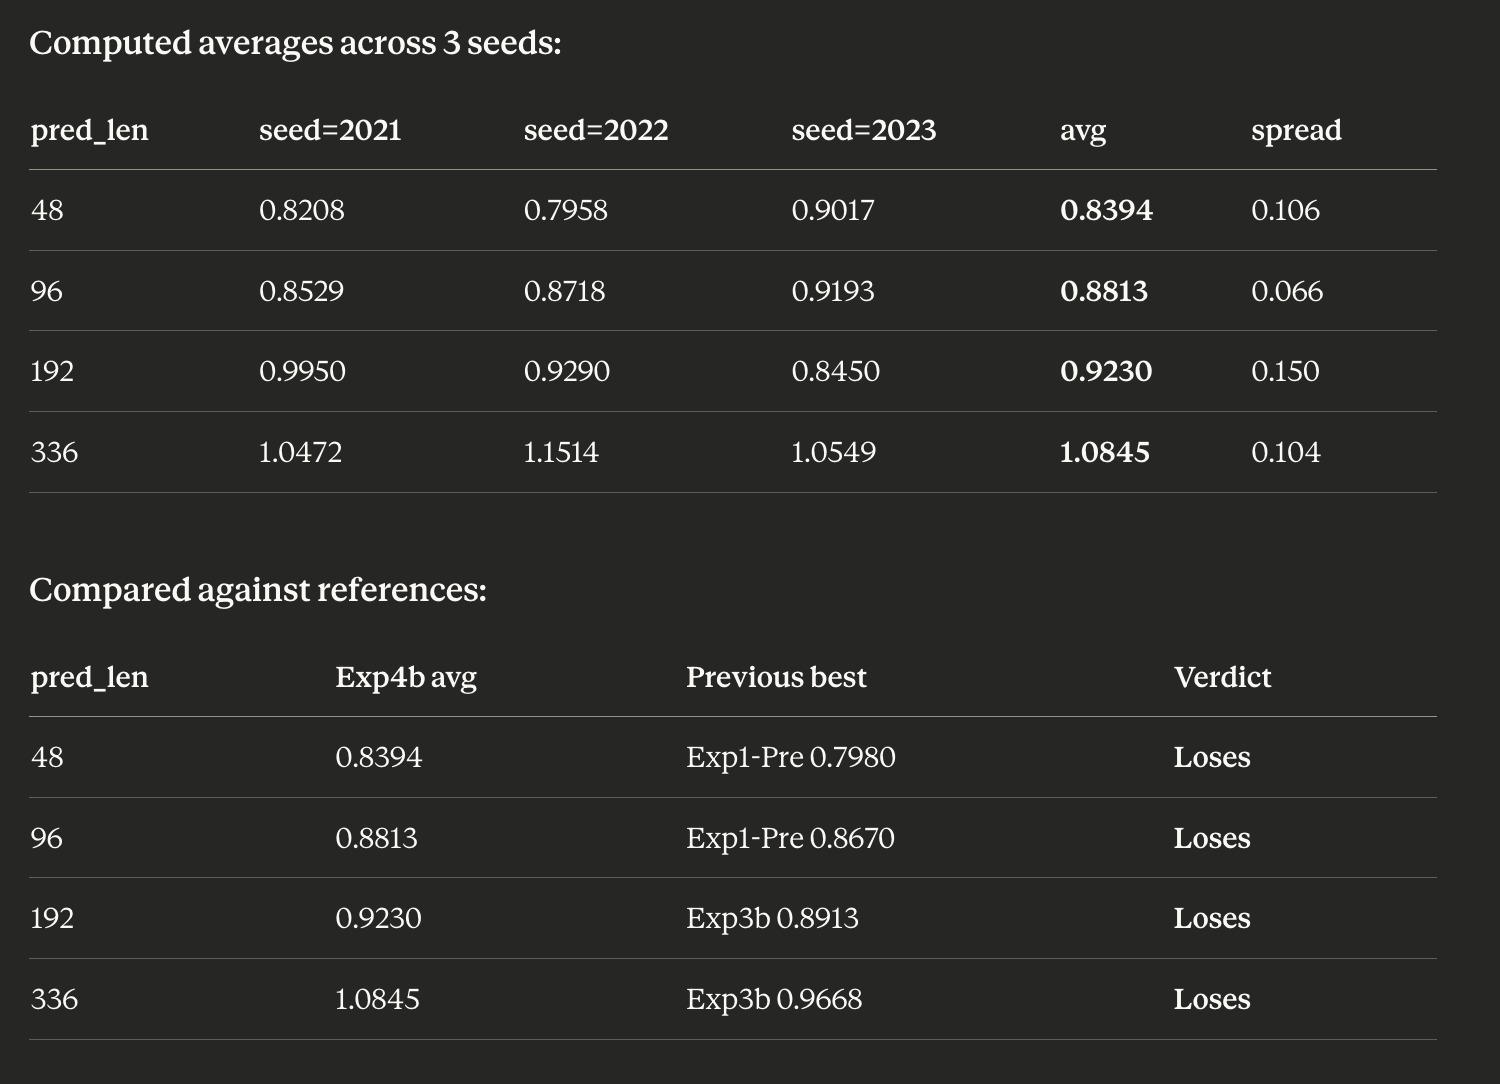

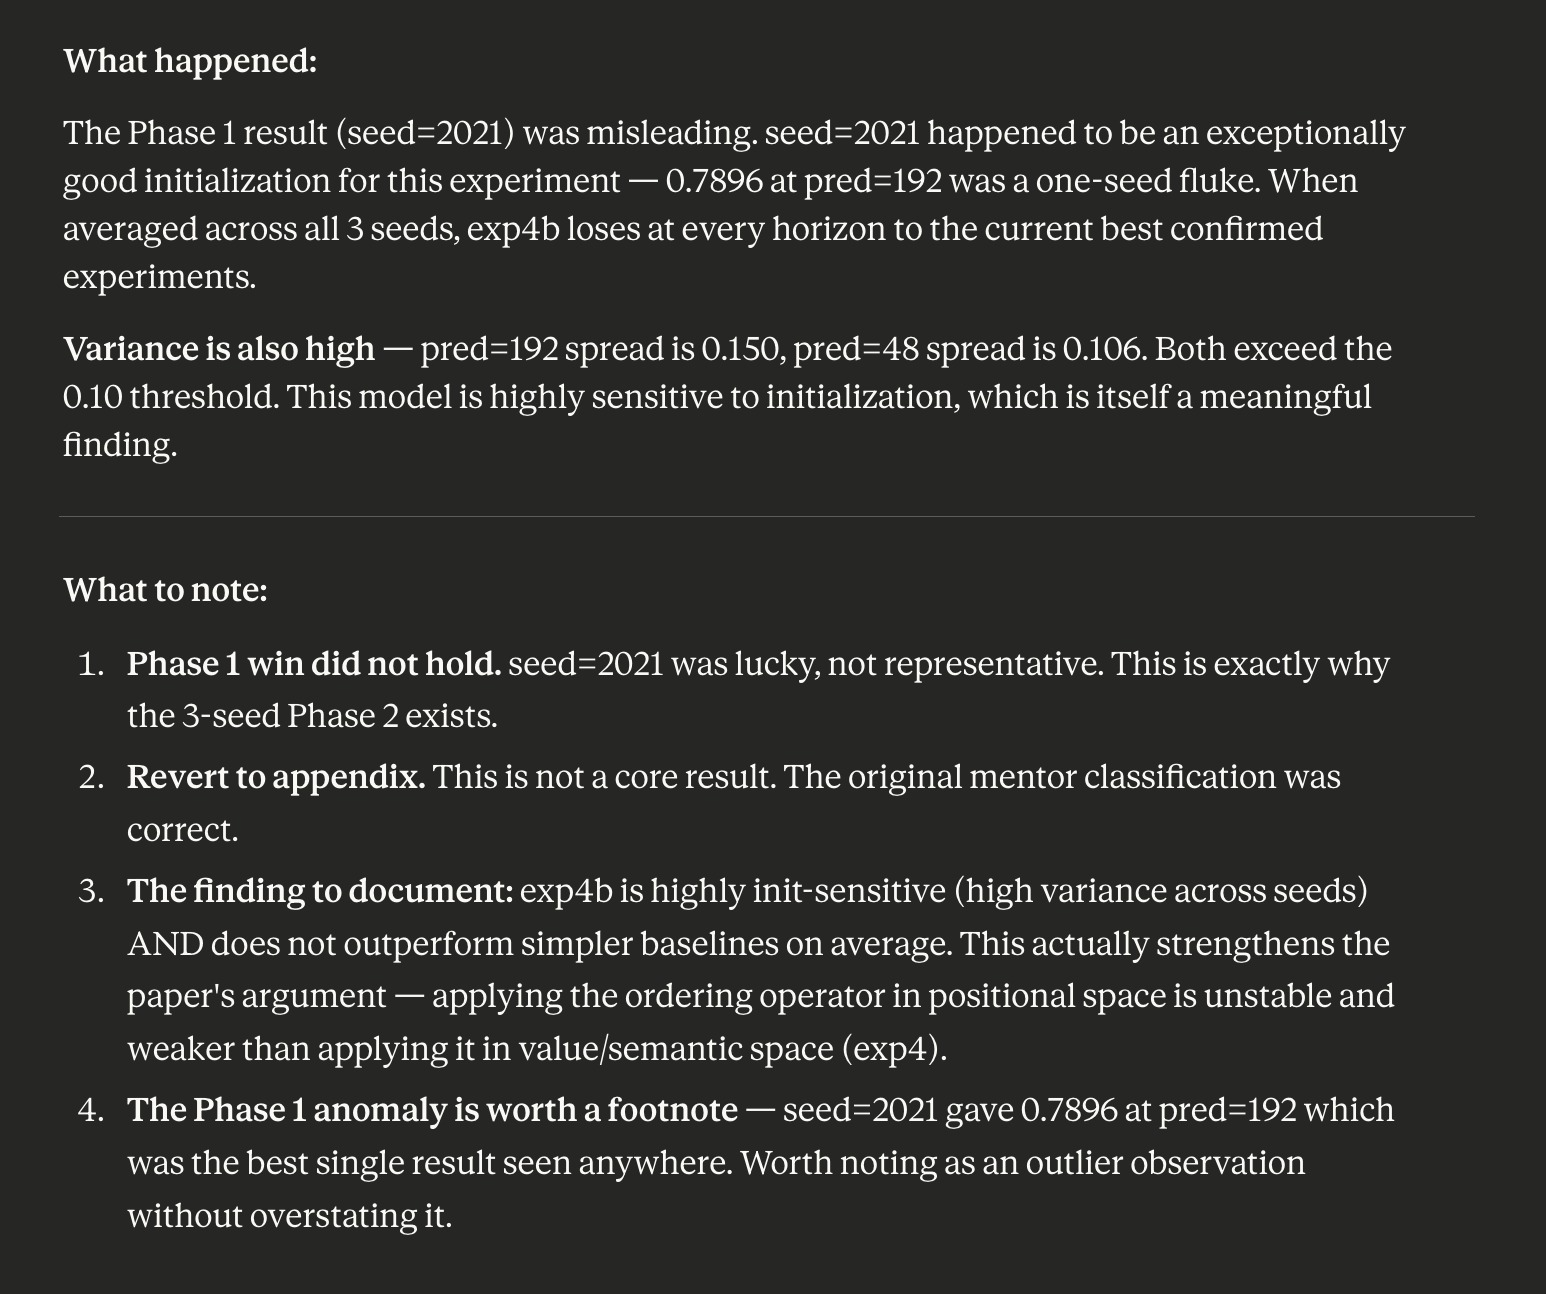

exp4b goes back to appendix.